## Ćwiczenie 1: Statystyczne wykresy seaborn (20 min)

In [3]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


#### Zadanie 1.1 — Barplot z hue (wzór do skopiowania)

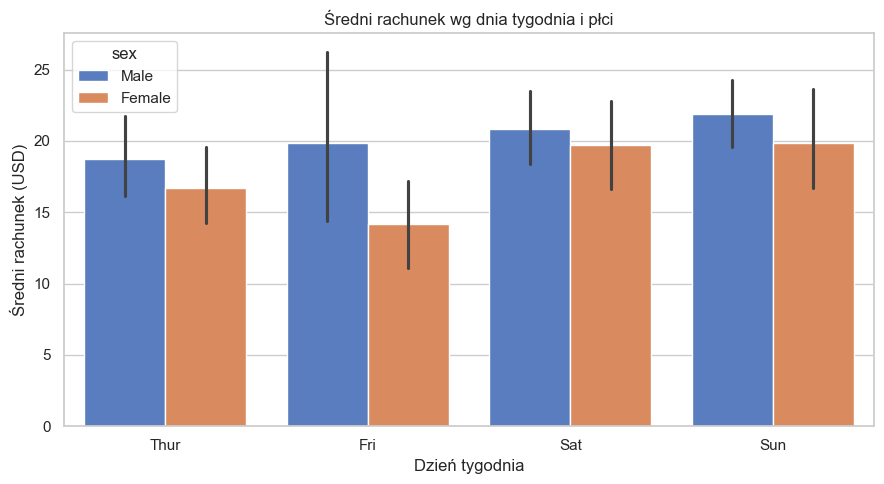

Zapisano: barplot_dzien_plec.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='sex',
    ax=ax,
    palette='muted',
    errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

#### Zadanie 1.2 — Boxplot (uzupełnij ???)

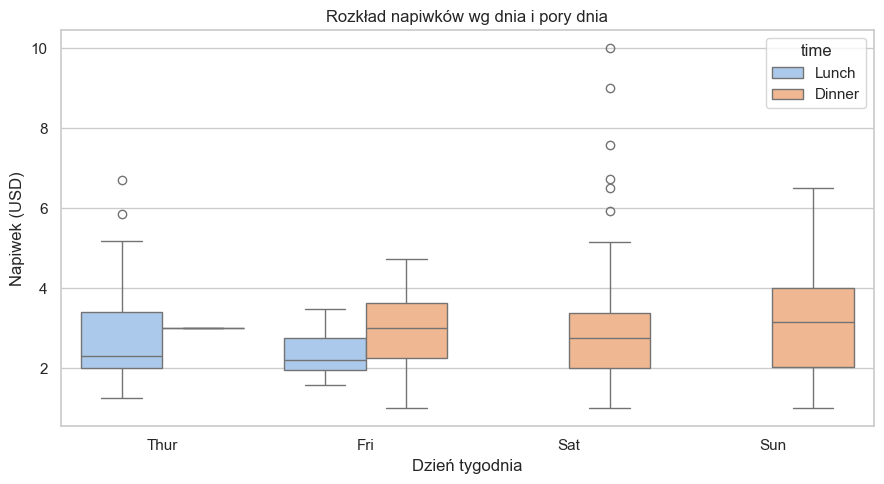

Zapisano: boxplot_napiwki.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=tips,
    x='day',        # kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
    y='tip',        # kolumna numeryczna na oś Y (napiwek)
    hue='time',     # podział kolorystyczny (Lunch/Dinner)
    ax=ax,
    palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

#### Zadanie 1.3 — Heatmap korelacji (uzupełnij ???)

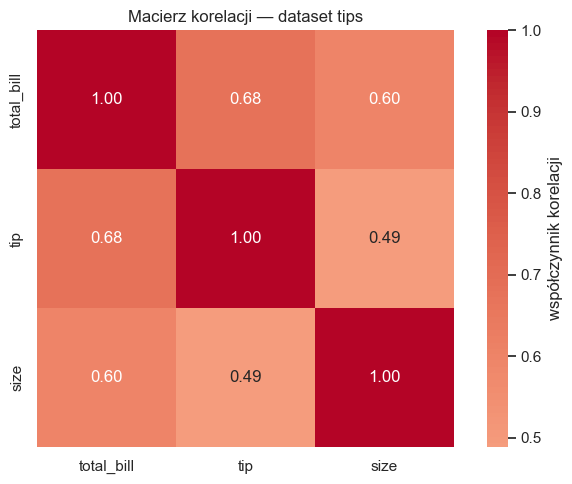

Zapisano: heatmap_korelacja.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()
sns.heatmap(
    corr,
    annot=True,          # True — pokaż liczby w komórkach
    fmt='.2f',          # 2 miejsca po przecinku
    cmap='coolwarm',     # 'coolwarm' — paleta dywergencyjna (czerwony=+, niebieski=-)
    center=0,            # 0 — środek skali (biały = 0 korelacja)
    ax=ax,
    square=True,
    cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

#### Zadanie 1.4 — Scatter z hue + style (samodzielnie)

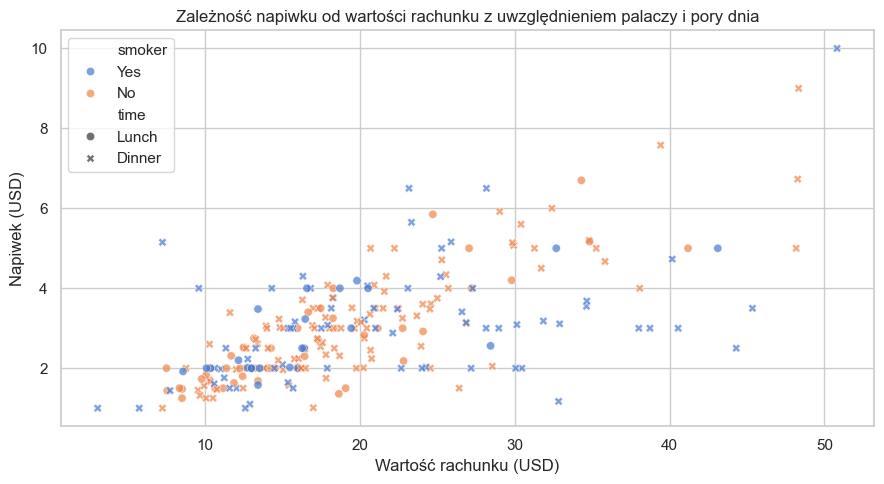

Zapisano: scatter_rachunek_napiwek.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

# Twój kod
sns.scatterplot(
    data=tips,
    x='total_bill',               # oś X: całkowity rachunek
    y='tip',                      # oś Y: napiwek
    hue='smoker',                 # kolor zależny od palenia (Yes/No)
    style='time',                 # kształt markera zależny od pory dnia (Lunch/Dinner)
    alpha=0.7,                    # lekka przezroczystość punktów
    ax=ax
)

# Ustawienia opisów wykresu
ax.set_title('Zależność napiwku od wartości rachunku z uwzględnieniem palaczy i pory dnia')
ax.set_xlabel('Wartość rachunku (USD)')
ax.set_ylabel('Napiwek (USD)')

plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: scatter_rachunek_napiwek.png")

## Ćwiczenie 2: Subplots, GridSpec, shared axes (20 min)

#### Zadanie 2.1 — Regularna siatka 2×2

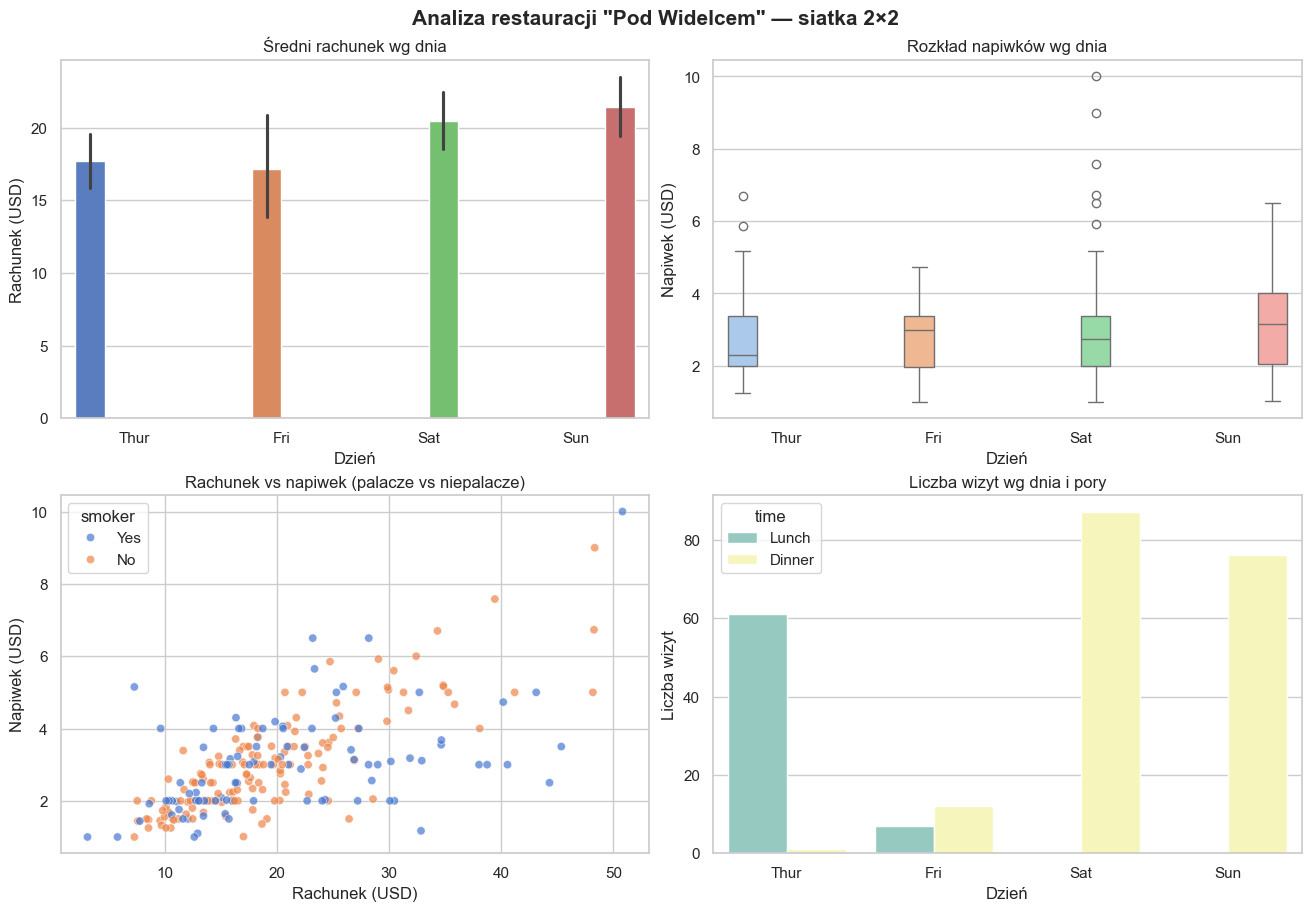

Zapisano: siatka_2x2.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
            ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')

# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
    data=tips,
    x='day',          # Dzień tygodnia na osi X
    y='tip',          # Wartość napiwku na osi Y
    hue='day', 
    legend=False,
    ax=axes[0, 1],
    palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')

# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
    data=tips,
    x='total_bill',   # Wartość rachunku na osi X
    y='tip',          # Wartość napiwku na osi Y
    hue='smoker',
    alpha=0.7,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')

# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
    data=tips,
    x='day',          # Dzień tygodnia na osi X (zlicza wystąpienia)
    hue='time',       # Podział słupków według pory dnia (Lunch/Dinner)
    ax=axes[1, 1],
    palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')

# Tytuł główny i zapis do pliku
fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2', fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

#### Zadanie 2.2 — GridSpec — nieregularny dashboard

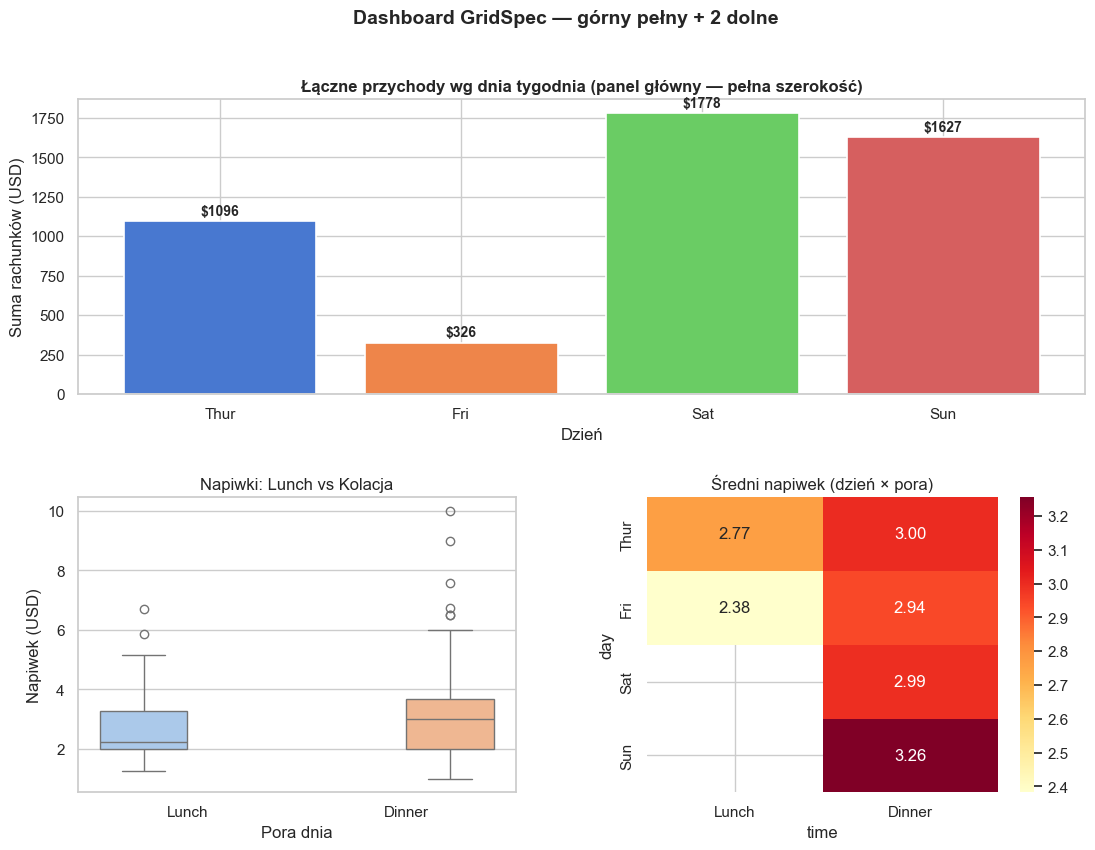

Zapisano: gridspec_dashboard.png


In [15]:
from matplotlib import gridspec

fig = plt.figure(figsize=(13, 9))

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Górny — pełna szerokość
ax_top = fig.add_subplot(gs[0, :])

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()

ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white',
    linewidth=1.2,
)

# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(
        i,
        val + 20,
        f'${val:.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax_top.set_title(
    'Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)',
    fontsize=12,
    fontweight='bold'
)

ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')


# Dolny lewy — boxplot
ax_bl = fig.add_subplot(gs[1, 0])

sns.boxplot(
    data=tips,
    x='time',
    y='tip',
    hue='time',
    legend=False,
    ax=ax_bl,
    palette='pastel',
)

ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')


# Dolny prawy — heatmap pivot
ax_br = fig.add_subplot(gs[1, 1])

pivot = tips.pivot_table(
    values='tip',
    index='day',
    columns='time',
    aggfunc='mean',
    observed=True
)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax_br,
)

ax_br.set_title('Średni napiwek (dzień × pora)')


fig.suptitle(
    'Dashboard GridSpec — górny pełny + 2 dolne',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'gridspec_dashboard.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: gridspec_dashboard.png")

#### Zadanie 2.3 — Shared axes (samodzielnie)

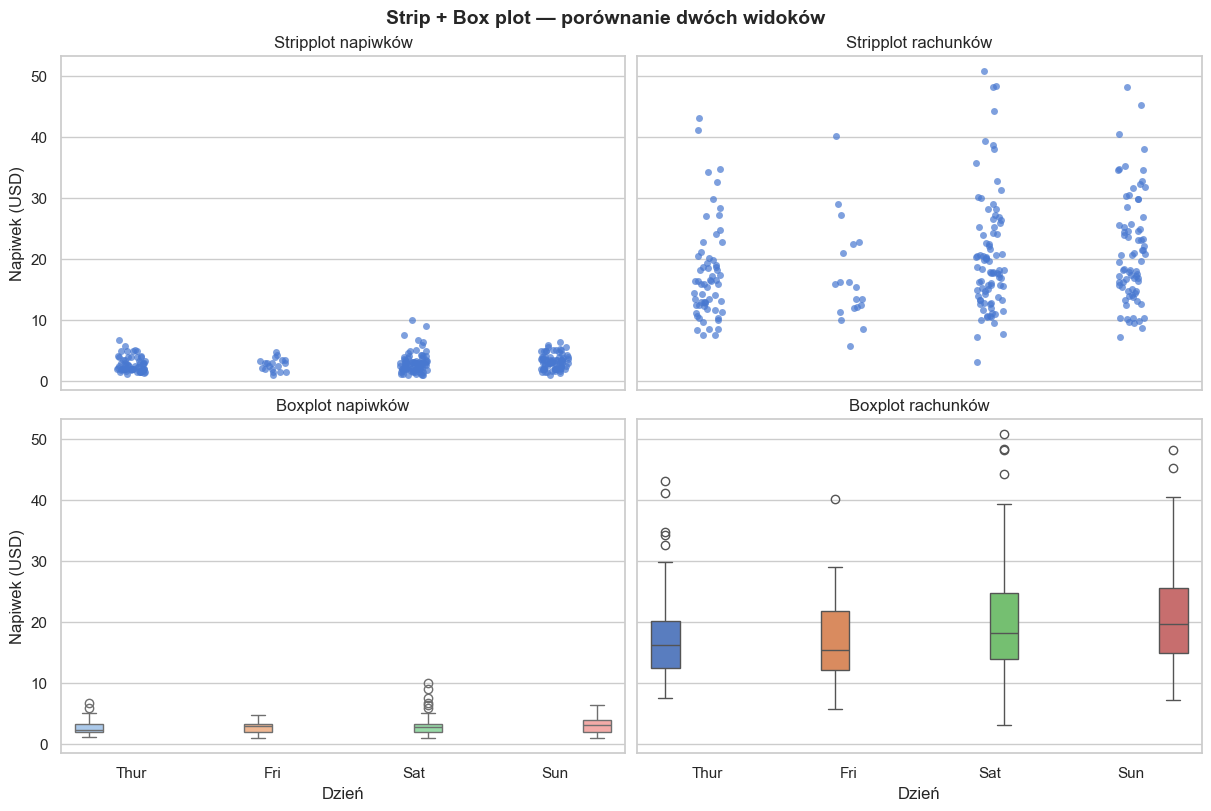

In [16]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex='col',
    sharey='row',
    constrained_layout=True
)

# axes[0, 0] stripplot napiwki
sns.stripplot(
    data=tips,
    x='day',
    y='tip',
    ax=axes[0, 0],
    alpha=0.7,
)

axes[0, 0].set_title('Stripplot napiwków')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Napiwek (USD)')


# axes[1, 0] boxplot napiwki
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day',
    legend=False,
    ax=axes[1, 0],
    palette='pastel',
)

axes[1, 0].set_title('Boxplot napiwków')
axes[1, 0].set_xlabel('Dzień')
axes[1, 0].set_ylabel('Napiwek (USD)')


# axes[0, 1] stripplot rachunki
sns.stripplot(
    data=tips,
    x='day',
    y='total_bill',
    ax=axes[0, 1],
    alpha=0.7,
)

axes[0, 1].set_title('Stripplot rachunków')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Rachunek (USD)')


# axes[1, 1] boxplot rachunki
sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='day',
    legend=False,
    ax=axes[1, 1],
    palette='muted',
)

axes[1, 1].set_title('Boxplot rachunków')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Rachunek (USD)')


fig.suptitle(
    'Strip + Box plot — porównanie dwóch widoków',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'shared_axes.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

## Ćwiczenie 3: Pełny dashboard analityczny (30 min) — praca samodzielna

#### Zadanie 3.1 — Projekt dashboardu (5 min)

In [17]:
# 1. Pytanie główne (KPI): W którym dniu restauracja zarabia najwięcej?
# -> Najwięcej zarabia w sobotę (Saturday), a zaraz za nią w niedzielę (Sunday).
# -> Wykres: sns.barplot z sumarycznym sumowaniem (estimator=sum) obrotu 'total_bill'.

# 2. Panele pomocnicze (Wnioski z dystrybucji, korelacji i struktury gości):
# -> Rozkład napiwków: Mediana napiwków oscyluje wokół 3 USD; występują liczne wartości odstające (powyżej 6 USD).
# -> Korelacja: Istnieje silna dodatnia korelacja między wielkością rachunku (total_bill) a wielkością napiwku (tip).
# -> Scatter rachunek-napiwek: Im wyższy rachunek, tym wyższy napiwek; palacze wykazują większą zmienność (rozrzut) zachowań.
# -> Proporcja dni: Najwięcej wizyt (najwyższa frekwencja) przypada na weekend (sobota i niedziela), dominują kolacje (Dinner).

# 3. Panel sumaryczny (Rozkład rachunków per dzień via violinplot):
# -> Wykres skrzypcowy pokazuje, że w weekendy (Sat/Sun) rozkład rachunków jest szerszy i przesunięty w stronę wyższych kwot.
# -> W dni powszednie (Thur/Fri) rachunki są bardziej skoncentrowane wokół niższej średniej, z wyraźnym podziałem na Lunch/Dinner.

#### Zadanie 3.2 — Implementacja dashboardu (20 min)

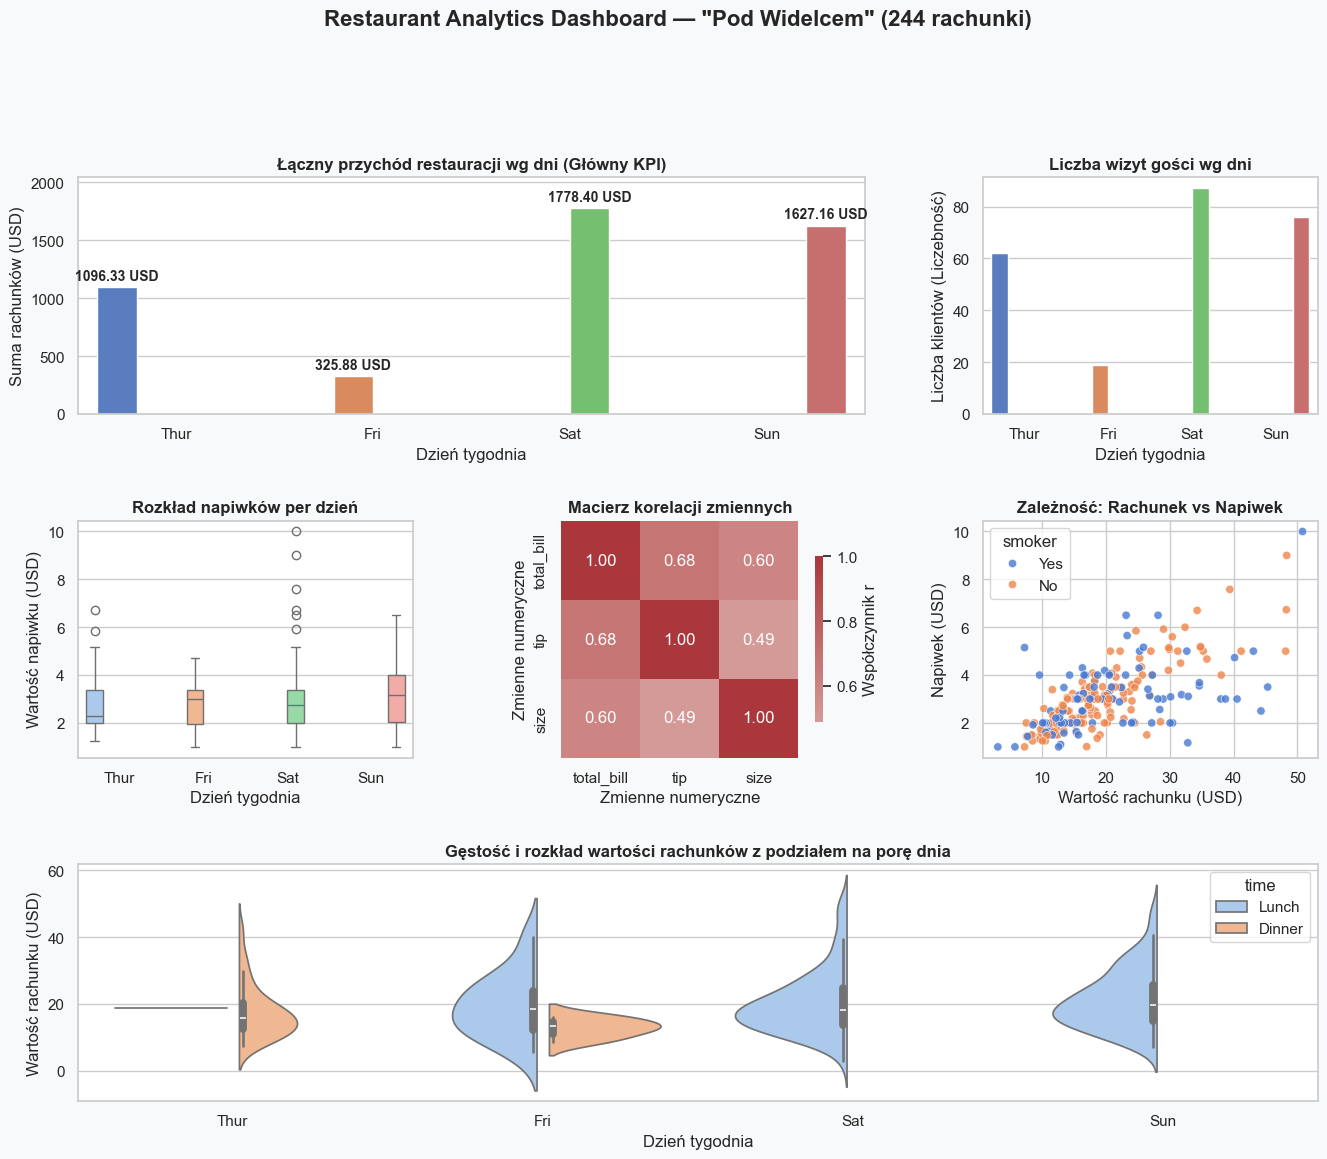

Zapisano: dashboard_pod_widelcem.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Ustawienie globalnego stylu seaborn dla spójności wizualnej
sns.set_theme(style="whitegrid")

# Restaurant Analytics Dashboard "Pod Widelcem"
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f8f9fa')  # tło figury — jasnoszare

# Siatka 3x3 — hspace i wspace dbają o to, by napisy na osiach się nie nakładały
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# =========================================================================
# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
# DOMINUJE WIZUALNIE — zajmuje 2 kolumny i 1 wiersz
# =========================================================================
ax1 = fig.add_subplot(gs[0, :2])
daily_revenue = tips.groupby('day', observed=False)['total_bill'].sum().reset_index()

# Użycie palety 'muted' zgodnie z wytycznymi
barplot = sns.barplot(
    data=daily_revenue, x='day', y='total_bill', 
    ax=ax1, palette='muted', hue='day', legend=False
)

# Dodanie etykiet wartości nad słupkami dla efektu KPI
for p in barplot.patches:
    barplot.annotate(
        f"{p.get_height():.2f} USD", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 8), 
        textcoords='offset points', fontweight='bold', fontsize=10
    )
ax1.set_title('Łączny przychód restauracji wg dni (Główny KPI)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dzień tygodnia')
ax1.set_ylabel('Suma rachunków (USD)')
ax1.set_ylim(0, daily_revenue['total_bill'].max() * 1.15)


# =========================================================================
# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
# Zmieniony z pie na countplot, aby PANEL MIAŁ ETYKIETY OSI X i Y
# =========================================================================
ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(data=tips, x='day', ax=ax2, palette='muted', hue='day', legend=False)
ax2.set_title('Liczba wizyt gości wg dni', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dzień tygodnia')
ax2.set_ylabel('Liczba klientów (Liczebność)')


# =========================================================================
# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
# =========================================================================
ax3 = fig.add_subplot(gs[1, 0])
# Używamy palety 'pastel' (młodsza siostra palety 'muted') dla zachowania spójności
sns.boxplot(data=tips, x='day', y='tip', ax=ax3, palette='pastel', hue='day', legend=False)
ax3.set_title('Rozkład napiwków per dzień', fontsize=12, fontweight='bold')
ax3.set_xlabel('Dzień tygodnia')
ax3.set_ylabel('Wartość napiwku (USD)')


# =========================================================================
# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
# =========================================================================
ax4 = fig.add_subplot(gs[1, 1])
corr = tips.select_dtypes('number').corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='vlag', # 'vlag' to elegancka, stonowana paleta
    center=0, ax=ax4, square=True, cbar_kws={'shrink': 0.7, 'label': 'Współczynnik r'}
)
ax4.set_title('Macierz korelacji zmiennych', fontsize=12, fontweight='bold')
ax4.set_xlabel('Zmienne numeryczne')
ax4.set_ylabel('Zmienne numeryczne')


# =========================================================================
# === PANEL 5: scatter (gs[1, 2]) ===
# =========================================================================
ax5 = fig.add_subplot(gs[1, 2])
# Spójna paleta 'muted' mapowana na status palacza
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', alpha=0.8, ax=ax5, palette='muted')
ax5.set_title('Zależność: Rachunek vs Napiwek', fontsize=12, fontweight='bold')
ax5.set_xlabel('Wartość rachunku (USD)')
ax5.set_ylabel('Napiwek (USD)')


# =========================================================================
# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
# =========================================================================
ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(
    data=tips, x='day', y='total_bill', hue='time', 
    split=True, ax=ax6, palette='pastel', gap=0.1
)
ax6.set_title('Gęstość i rozkład wartości rachunków z podziałem na porę dnia', fontsize=12, fontweight='bold')
ax6.set_xlabel('Dzień tygodnia')
ax6.set_ylabel('Wartość rachunku (USD)')


# =========================================================================
# === USTAWIENIA NADRZĘDNE I EKSPORT ===
# =========================================================================
# Tytuł nadrzędny (fig.suptitle) z lekkim odsunięciem (y=1.02)
fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
             fontsize=16, fontweight='bold', y=1.02)

# Eksport do PNG z zachowaniem jasnego tła, odpowiednim dpi i usunięciem białych marginesów
plt.savefig('dashboard_pod_widelcem.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
plt.close()

print("Zapisano: dashboard_pod_widelcem.png")

## Ćwiczenie 4: Style, eksport, adnotacja, commit (15 min)

#### Zadanie 4.1 — Porównanie stylów seaborn (5 min)

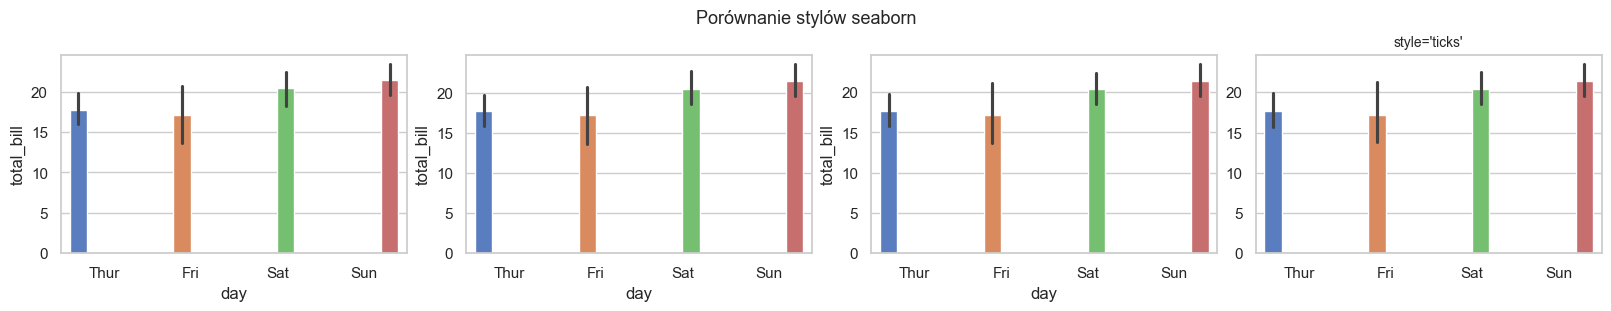

In [21]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
    with sns.axes_style(style): # context manager — tymczasowo zmień styl
        sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
ax=ax, palette='muted')
ax.set_title(f"style='{style}'", fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()

#### Zadanie 4.2 — Adnotacja na wykresie (5 min)

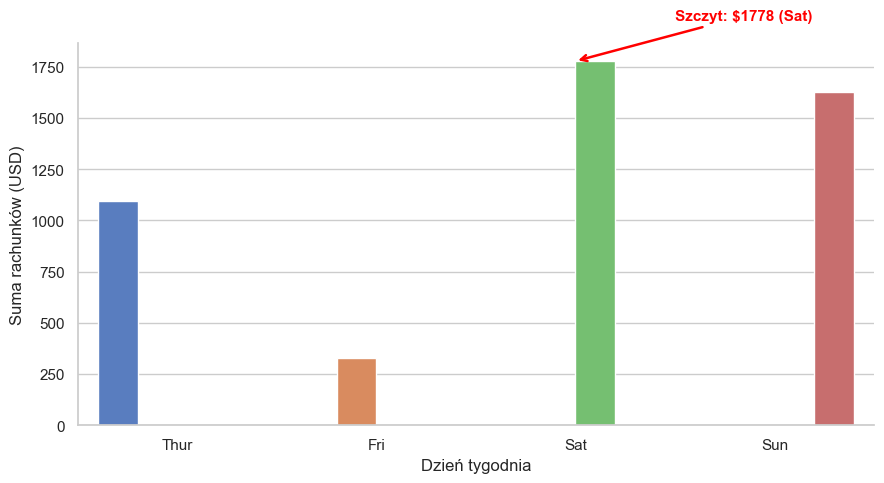

Zapisano: szczyt_przychodow.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
            ax=ax, palette='muted')

# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

# Adnotacja ze strzałką
ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),                 # punkt na który wskazuje strzałka — czubek słupka
    xytext=(max_idx + 0.5, max_val + 200), # gdzie tekst — przesunięty w prawo i do góry
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11, color='red', fontweight='bold',
)

# Tytuł celowo pominięty — adnotacja 'Szczyt: $...' sama w sobie informuje o czym wykres
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine() # usuwa górną i prawą krawędź osi (minimalistyczny styl)

plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")

#### Zadanie 4.3 — Commit do repozytorium (5 min)